<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Rain gauge optimisation
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p>This code works on defining optimal locations for placements of new rain gauges in the Upper Severn catchment. The placement of the gauges aims to optimise the accuracy with which rainfall over the catchment can be predicted. </p>

  <p><strong>The following data is available:</strong></p>
  <ul>
    <li> 1km HAD-UK gridded annual (?) rainfall data </li>
    <li> Rain gauge data from 10? existing rain gauges</li>
    <li> 30m (?) DEM data: from which slope and aspect can be derived. These are then aggregated to 1km </li>      
  </ul>
<!-- 
  <div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    <strong>NB:</strong> The threshold for an "unphysical" value is 
    currently set at <strong>150mm/hr</strong> — selected relatively 
    arbitrarily and may need review.
  </div> -->

</div>

In [1]:
import glob
import iris
import iris.coords as icoords
from pyproj import Transformer
import importlib
import pandas as pd

# import random
import functions
importlib.reload(functions)
from functions import *

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"

ceh_gear_dir = "/scratch/hydro4/shared_data/climate_observed/CEH-GEAR/hourly/1km/"

catchment = gpd.read_file(data_dir + "54080/54080.shp")

In [2]:
# Load rain gauge metadata
rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")

# Convert to GeoDataFrame (BNG coordinates)
rain_meta_sf = gpd.GeoDataFrame(rain_meta_cmd, geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
                                crs="EPSG:27700");

### Get CEH-GEAR-1km gridded rainfall data

In [3]:
filenames=[]

for year in range(2016,2017):
    general_filename = ceh_gear_dir + f'CEH-GEAR-1hr-v2_{year}*'
    for filename in glob.glob(general_filename):
        filenames.append(filename)
print(len(filenames))

monthly_cubes_list = iris.load(filenames)

rain_cubes = [c for c in monthly_cubes_list if c.name() == 'rainfall_amount']
rain_cubes = iris.cube.CubeList(rain_cubes)
obs_cube = rain_cubes[0]

cubes = iris.load(filenames)

rain_cubes = iris.cube.CubeList([c for c in cubes if c.name() == 'rainfall_amount'])

for c in rain_cubes:
    c.attributes = {}   # 🔥 remove all conflicting attributes

ceh_gear = rain_cubes.concatenate_cube()
ceh_gear_trimmed = trim_to_bbox_of_region_obs(ceh_gear, catchment, 'projection_y_coordinate', 'projection_x_coordinate', 1)

12


/home/kv25483/anaconda3/envs/geo_env2/lib/python3.10/site-packages/iris/__init__.py:680: FutureWarning: Ignoring a datum in netCDF load for consistency with existing behaviour. In a future version of Iris, this datum will be applied. To apply the datum when loading, use the iris.FUTURE.datum_support flag.
  cubes = _load_collection(uris, constraints, callback).combined().cubes()


### Trim the CEH-GEAR data to only cover a region around the catchment (1km buffer)

In [4]:
ceh_gear_trimmed = trim_to_bbox_of_region_obs(ceh_gear, catchment, 'projection_y_coordinate', 'projection_x_coordinate', 1)

### Find the max/mean hourly rainfall values 

In [5]:
data = ceh_gear_trimmed.data  # (time, y, x)
# Find the max/mean hourly data
mean_hourly = np.nanmean(data, axis=0)
max_hourly = np.nanmax(data, axis=0)
# Find the mean hourly data in the hours within which it was raining
wet_data = np.where(data > 0, data, np.nan)
mean_wet_hourly = np.nanmean(wet_data, axis=0)

In [6]:
y = ceh_gear_trimmed.coord('projection_y_coordinate')
x = ceh_gear_trimmed.coord('projection_x_coordinate')

mean_hourly_cube = iris.cube.Cube(mean_hourly, var_name="mean_hourly_rainfall",units=ceh_gear_trimmed.units,
                                  dim_coords_and_dims=[(y.copy(), 0), (x.copy(), 1)])

max_hourly_cube = iris.cube.Cube(max_hourly, var_name="max_hourly_rainfall",units=ceh_gear_trimmed.units,
                                  dim_coords_and_dims=[(y.copy(), 0), (x.copy(), 1)])

mean_wet_cube = iris.cube.Cube(mean_wet_hourly, var_name="mean_hourly_wet_rainfall",units=ceh_gear_trimmed.units,
                                  dim_coords_and_dims=[(y.copy(), 0), (x.copy(), 1)])

### Plot

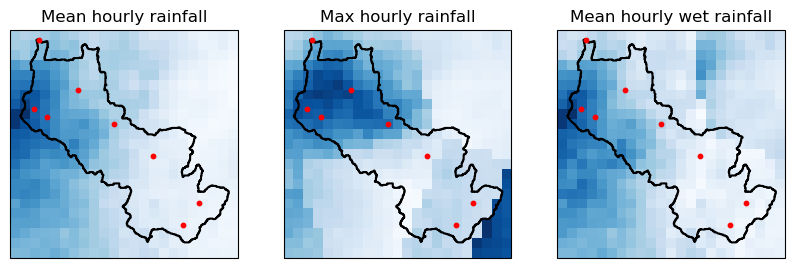

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import iris.plot as iplt

fig, axs= plt.subplots(ncols=3, figsize=(10,5), subplot_kw={'projection': ccrs.OSGB()})

# --- plot rainfall slice ---
iplt.pcolormesh(mean_hourly_cube,axes=axs[0], cmap='Blues')
catchment.boundary.plot(ax=axs[0], edgecolor='black',linewidth=1.5, transform=ccrs.OSGB())
axs[0].coastlines(resolution='10m')
axs[0].set_title("Mean hourly rainfall")
rain_meta_sf.plot(ax=axs[0], color='red', markersize=10, label='Existing gauges', zorder=5);

iplt.pcolormesh(max_hourly_cube,axes=axs[1], cmap='Blues')
catchment.boundary.plot(ax=axs[1], edgecolor='black',linewidth=1.5, transform=ccrs.OSGB())
axs[1].coastlines(resolution='10m')
axs[1].set_title("Max hourly rainfall")
rain_meta_sf.plot(ax=axs[1], color='red', markersize=10, label='Existing gauges', zorder=5);

iplt.pcolormesh(mean_wet_cube,axes=axs[2], cmap='Blues')
catchment.boundary.plot(ax=axs[2], edgecolor='black',linewidth=1.5, transform=ccrs.OSGB())
axs[2].coastlines(resolution='10m')
axs[2].set_title("Mean hourly wet rainfall");
rain_meta_sf.plot(ax=axs[2], color='red', markersize=10, label='Existing gauges', zorder=5);